<a href="https://colab.research.google.com/github/AbdulMalik300/auto-mpg-fuel-efficiency-analysis/blob/main/auto_mpg_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
import os
# Create folder to save visualizations
os.makedirs('visualizations', exist_ok=True)

## 2. Load and Understand the Dataset

In [47]:
# Load the dataset directly from URL
url = 'https://raw.githubusercontent.com/plotly/datasets/master/auto-mpg.csv'
df=pd.read_csv(url)
df.head()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model-year
0,18.0,8,307.0,130.0,3504,12.0,70
1,15.0,8,350.0,165.0,3693,11.5,70
2,18.0,8,318.0,150.0,3436,11.0,70
3,16.0,8,304.0,150.0,3433,12.0,70
4,17.0,8,302.0,140.0,3449,10.5,70


In [48]:
# Check dataset structure and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    396 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model-year    398 non-null    int64  
dtypes: float64(4), int64(3)
memory usage: 21.9 KB


## 3. Data Cleaning
Checking and handling missing values and duplicate rows before analysis.

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,2
weight,0
acceleration,0
model-year,0


In [ ]:
df['horsepower']=pd.to_numeric(df['horsepower'],errors='coerce')

In [ ]:
df.isnull().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,2
weight,0
acceleration,0
model-year,0


In [ ]:
df['horsepower'].fillna(df['horsepower'].median(),inplace= True)

/tmp/ipykernel_2912/2567308185.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(),inplace= True)


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

## 4. Basic Statistics
Calculating mean, minimum, and maximum MPG using NumPy.

In [49]:
# Calculate basic statistics for MPG
print("Mean MPG:", np.mean(df['mpg']))
print("Min MPG:", np.min(df['mpg']))
print("Max MPG:", np.max(df['mpg']))

Mean MPG: 23.514572864321607
Min MPG: 9.0
Max MPG: 46.6


## 5. Filtering Data
Filtering cars based on MPG, horsepower, and weight.

In [ ]:
high_efficiency = df[df['mpg'] > 30]
low_power_light=df[(df['horsepower']<100) & (df['weight']<2500)]

In [ ]:
print(f"High Efficiency Cars:{high_efficiency}")
print(f"\nLow Power and Light Cars{low_power_light}:")

High Efficiency Cars:      mpg  cylinders  displacement  horsepower  weight  acceleration  \
53   31.0          4          71.0        65.0    1773          19.0   
54   35.0          4          72.0        69.0    1613          18.0   
129  31.0          4          79.0        67.0    1950          19.0   
131  32.0          4          71.0        65.0    1836          21.0   
144  31.0          4          76.0        52.0    1649          16.5   
..    ...        ...           ...         ...     ...           ...   
390  32.0          4         144.0        96.0    2665          13.9   
391  36.0          4         135.0        84.0    2370          13.0   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model-year  
53           71  
54           71  
129          74  
131          74  
144          74  
..    

## 6. Visualizations
Exploring relationships between MPG and other factors.


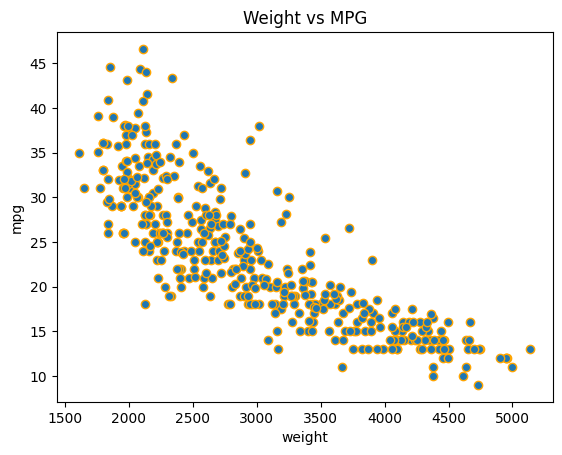

In [42]:
# Graph 1: Scatter - weight vs mpg
plt.scatter(df['weight'],df['mpg'],edgecolors='orange')
plt.xlabel('weight')
plt.ylabel('mpg')
plt.title('Weight vs MPG')
plt.savefig('visualizations/mpg_vs_weight.png')
plt.show()

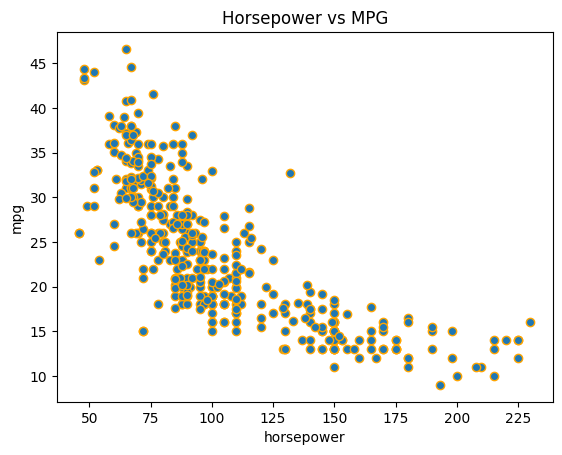

In [43]:
# Graph 2: Scatter - horsepower vs mpg
plt.scatter(df['horsepower'],df['mpg'],edgecolors='orange')
plt.xlabel('horsepower')
plt.ylabel('mpg')
plt.title('Horsepower vs MPG')
plt.savefig('visualizations/mpg_vs_horsepower.png')
plt.show()

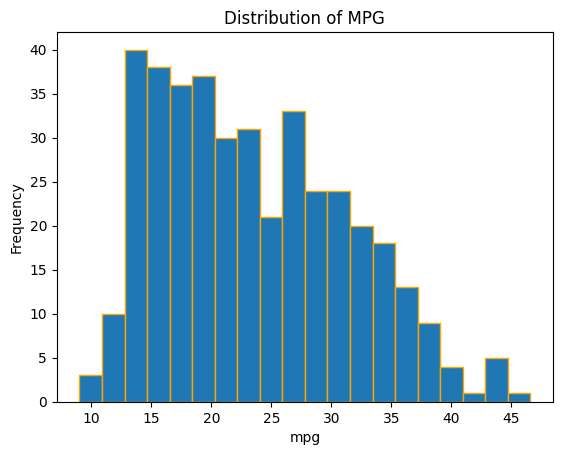

In [44]:
# Graph 3: Histogram - mpg distribution
plt.hist(df['mpg'],bins=20,edgecolor='orange')
plt.xlabel('mpg')
plt.ylabel('Frequency')
plt.title('Distribution of MPG')
plt.savefig('visualizations/mpg_distribution.png')
plt.show()


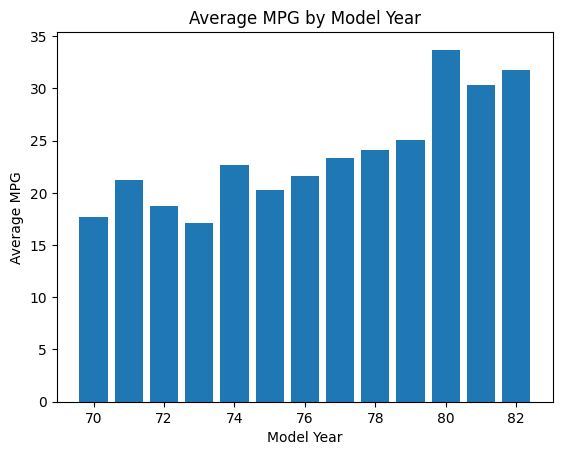

In [45]:
# Graph 4: Bar - avg mpg by model year
avg_mpg_by_year=df.groupby('model-year')['mpg'].mean()
plt.bar(avg_mpg_by_year.index,avg_mpg_by_year.values)
plt.xlabel('Model Year')
plt.ylabel('Average MPG')
plt.title('Average MPG by Model Year')
plt.savefig('visualizations/mpg_by_year.png')
plt.show()

In [41]:
prob = np.sum(df['mpg'] > 30) / len(df)
print(f"Probability of MPG > 30: {prob:.2%}")

Probability of MPG > 30: 21.36%


##7. Findings

1. Heavier cars have lower fuel efficiency — as weight increases, MPG tends to decrease.
2. Cars with higher horsepower generally show lower MPG, likely because more powerful engines consume more fuel.

3.Most cars in the dataset have an MPG between 15-25, indicating
that very high fuel efficiency is uncommon.

4.Average MPG has improved over the years, suggesting better fuel efficiency technology in newer car models.

5.Only about 21.36% of cars in the dataset have an MPG greater than 30, showing that highly fuel-efficient cars are relatively rare.




